<div style="text-align: center;">
    <a href="https://www.hi-paris.fr/">
        <img border="0" src="https://www.hi-paris.fr/wp-content/uploads/2020/09/logo-hi-paris-retina.png" width="25%"></a>
    <a href="https://www.dataia.eu/">
        <img border="0" src="https://github.com/ramp-kits/template-kit/raw/main/img/DATAIA-h.png" width="70%"></a>
</div>

# Template Kit for Cadabench challenge in the Datacamp

<i> Thomas Moreau (Inria) </i><br/>
<i> Pedro Rodrigues (Inria) </i>

## Introduction

- Where the data comes from?
The dataset used in this challenge is built from several public environmental sound datasets:

* **ESC-50** — a collection of short labeled environmental sound clips (Piczak, 2015).
* **UrbanSound8K** — a large dataset of urban sounds such as sirens, drilling, or dog barking (Salamon et al., 2014).
* **FSD50K** — a large-scale dataset of human-labeled sound events collected from Freesound (Fonseca et al., 2022).

In this challenge, these datasets are combined and filtered to create a collection of audio clips containing both **emergency sounds** and **non-emergency background sounds**.

- What is the task this challenge aims to solve?
The goal of the challenge is **emergency audio event detection**.

For each audio clip, participants must:

* detect whether an emergency sound occurs
* predict the **start and end time** of the event

If no emergency is detected, the model should return no segments.

- Why does it matter?

Automatically detecting emergency sounds can be useful in many real-world applications, such as:

* autonomous driving
* public safety monitoring
* smart city systems
* surveillance and security
* assistive technologies

This task is challenging because models must **both recognize emergency sounds and locate them in time** within the audio.

### References

* Piczak, K. J. (2015). *ESC: Dataset for Environmental Sound Classification.* Proceedings of the 23rd ACM International Conference on Multimedia. DOI: [http://dx.doi.org/10.1145/2733373.2806390](http://dx.doi.org/10.1145/2733373.2806390)
* Salamon, J., Jacoby, C., & Bello, J. P. (2014). *A Dataset and Taxonomy for Urban Sound Research.* Proceedings of the 22nd ACM International Conference on Multimedia.
* Fonseca, E., Favory, X., Pons, J., Font, F., & Serra, X. (2022). *FSD50K: an open dataset of human-labeled sound events.* IEEE/ACM Transactions on Audio, Speech, and Language Processing.

# Exploratory data analysis

The goal of this section is to show what's in the data, and how to play with it.
This is the first set in any data science project, and here, you should give a sense of the data the participants will be working with.

You can first load and describe the data, and then show some interesting properties of it.

In [10]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import soundfile as sf
import librosa
import librosa.display
from tqdm import tqdm

from IPython.display import Audio, display

pd.set_option("display.max_columns", None)

data_dir = Path("dev_phase/input_data")

# Load training metadata
train_features = pd.read_csv(data_dir / "train" / "train_features.csv")
train_labels = pd.read_csv(data_dir / "train" / "train_labels.csv")

print("Number of training clips:", len(train_features))
print("Number of annotated emergency events:", len(train_labels))

train_features.head()

Number of training clips: 7541
Number of annotated emergency events: 1641


,sample_id,audio_path
0,00019293a2c850c5,audio/00019293a2c850c5.wav
1,000d4f5676987b2e,audio/000d4f5676987b2e.wav
2,000f258bca7a6a9c,audio/000f258bca7a6a9c.wav
3,0013a9ff47ad6405,audio/0013a9ff47ad6405.wav
4,00161fd9e0a3dc22,audio/00161fd9e0a3dc22.wav


In [11]:
clips_with_event = set(train_labels.sample_id)
clips_without_event = set(train_features.sample_id) - clips_with_event

print("Clips with emergency:", len(clips_with_event))
print("Clips without emergency:", len(clips_without_event))

Clips with emergency: 1641
Clips without emergency: 5900


Temporal Sparsity & Imbalance


Scanning audio durations: 100%|██████████| 7541/7541 [01:16<00:00, 97.94it/s] 



Total Dataset Duration: 8.58 hours
Total Emergency Event Duration: 1.64 hours
Total Background/Negative Duration: 6.95 hours
Dataset Temporal Sparsity: 19.05% of the audio contains an emergency.


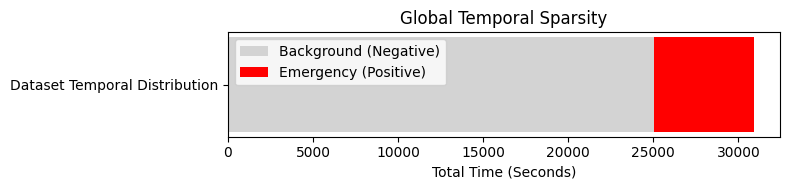

In [12]:
print("Temporal Sparsity & Imbalance")
total_emergency_duration = (train_labels['end'] - train_labels['start']).sum()
total_audio_duration = 0
for path in tqdm(train_features['audio_path'], desc="Scanning audio durations"):
    full_path = data_dir / "train" / path
    info = sf.info(full_path)
    total_audio_duration += info.duration

background_duration = total_audio_duration - total_emergency_duration
sparsity_ratio = (total_emergency_duration / total_audio_duration) * 100

print(f"\nTotal Dataset Duration: {total_audio_duration / 3600:.2f} hours")
print(f"Total Emergency Event Duration: {total_emergency_duration / 3600:.2f} hours")
print(f"Total Background/Negative Duration: {background_duration / 3600:.2f} hours")
print(f"Dataset Temporal Sparsity: {sparsity_ratio:.2f}% of the audio contains an emergency.")

plt.figure(figsize=(8, 2))
plt.barh(['Dataset Temporal Distribution'], [background_duration], color='lightgray', label='Background (Negative)')
plt.barh(['Dataset Temporal Distribution'], [total_emergency_duration], left=[background_duration], color='red', label='Emergency (Positive)')
plt.xlabel('Total Time (Seconds)')
plt.legend()
plt.title('Global Temporal Sparsity')
plt.tight_layout()
plt.show()

Sample rate: 16000
Duration (seconds): 4.0


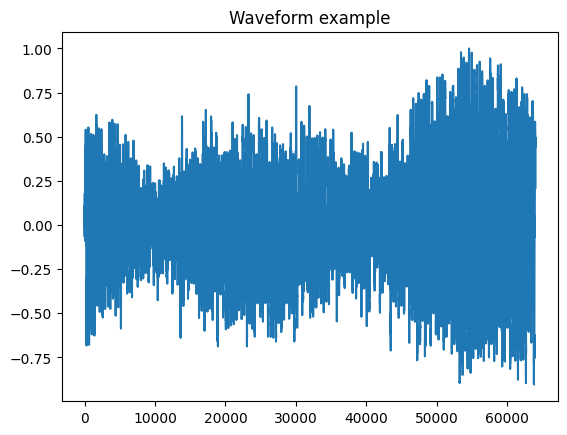

In [13]:
sample_indx = np.random.choice(train_features.index)
sample = train_features.loc[sample_indx]

audio_path = data_dir / "train" / sample.audio_path
audio, sr = sf.read(audio_path)

print("Sample rate:", sr)
print("Duration (seconds):", len(audio) / sr)

plt.plot(audio)
plt.title("Waveform example")
plt.show()

Audio(audio, rate=sr)

Example of Mel-spectograms of an emergency event segment and that of strictly background noise

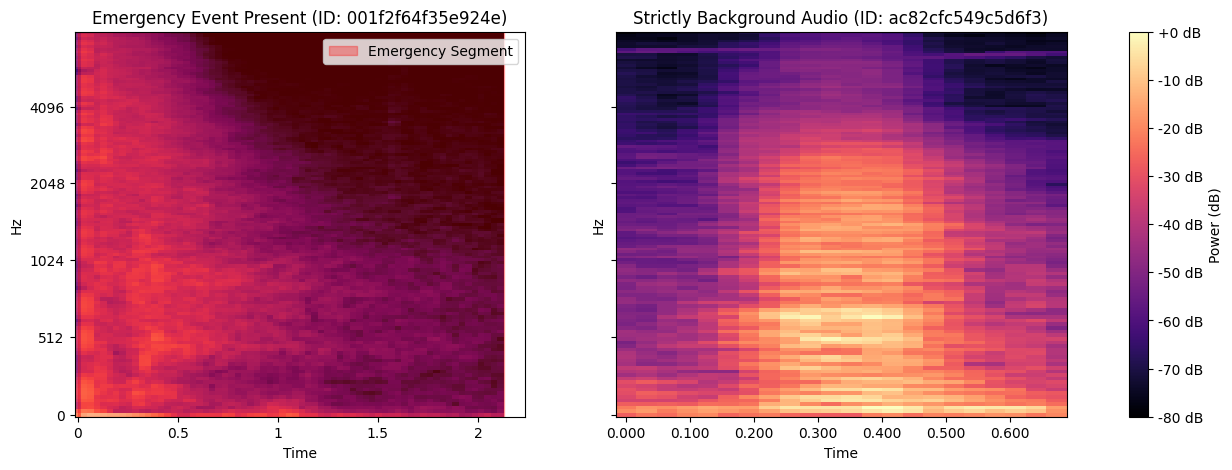

In [24]:
clips_with_event = set(train_labels.sample_id)
clips_without_event = list(set(train_features.sample_id) - clips_with_event)

sample_id_pos = train_labels['sample_id'].iloc[1]
sample_id_neg = clips_without_event[1]

path_pos = data_dir / "train" / train_features[train_features['sample_id'] == sample_id_pos]['audio_path'].values[0]
path_neg = data_dir / "train" / train_features[train_features['sample_id'] == sample_id_neg]['audio_path'].values[0]
y_pos, sr_pos = librosa.load(path_pos, sr=None)
y_neg, sr_neg = librosa.load(path_neg, sr=None)

#Compute Mel-spectrograms
S_pos = librosa.power_to_db(librosa.feature.melspectrogram(y=y_pos, sr=sr_pos, n_fft=2048, hop_length=512, n_mels=128), ref=np.max)
S_neg = librosa.power_to_db(librosa.feature.melspectrogram(y=y_neg, sr=sr_neg, n_fft=2048, hop_length=512, n_mels=128), ref=np.max)


fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
img1 = librosa.display.specshow(S_pos, x_axis='time', y_axis='mel', sr=sr_pos, hop_length=512, ax=axes[0])
axes[0].set_title(f'Emergency Event Present (ID: {sample_id_pos})')
events = train_labels[train_labels['sample_id'] == sample_id_pos]
for _, event in events.iterrows():
    axes[0].axvspan(event['start'], event['end'], color='red', alpha=0.3, label='Emergency Segment')
axes[0].legend(loc='upper right')
img2 = librosa.display.specshow(S_neg, x_axis='time', y_axis='mel', sr=sr_neg, hop_length=512, ax=axes[1])
axes[1].set_title(f'Strictly Background Audio (ID: {sample_id_neg})')

fig.colorbar(img1, ax=axes, format='%+2.0f dB', label='Power (dB)')
plt.show()

The associated audio clips for the spectograms

In [25]:
print(f" Emergency Event Audio (ID: {sample_id_pos})")
display(Audio(data=y_pos, rate=sr_pos))

print(f"\n Strictly Background Audio (ID: {sample_id_neg})")
display(Audio(data=y_neg, rate=sr_neg))

 Emergency Event Audio (ID: 001f2f64f35e924e)



 Strictly Background Audio (ID: ac82cfc549c5d6f3)


<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\DELL\AppData\Local\Temp\ipykernel_24304\2962060027.py:20: SyntaxWarning: invalid escape sequence '\s'
  f'$\sigma$ = {std_dur:.2f}s',


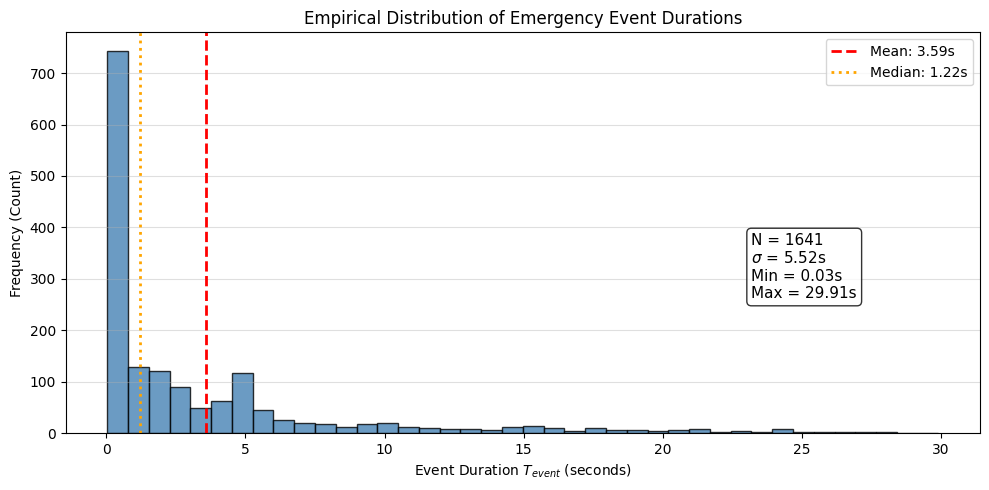

In [16]:
train_labels['duration'] = train_labels['end'] - train_labels['start']

mean_dur = train_labels['duration'].mean()
median_dur = train_labels['duration'].median()
std_dur = train_labels['duration'].std()

plt.figure(figsize=(10, 5))
counts, bins, patches = plt.hist(train_labels['duration'], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(mean_dur, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_dur:.2f}s')
plt.axvline(median_dur, color='orange', linestyle='dotted', linewidth=2, label=f'Median: {median_dur:.2f}s')

plt.title('Empirical Distribution of Emergency Event Durations')
plt.xlabel('Event Duration $T_{event}$ (seconds)')
plt.ylabel('Frequency (Count)')
plt.legend()
plt.grid(axis='y', alpha=0.4)

textstr = '\n'.join((
    f'N = {len(train_labels)}',
    f'$\sigma$ = {std_dur:.2f}s',
    f'Min = {train_labels["duration"].min():.2f}s',
    f'Max = {train_labels["duration"].max():.2f}s'))
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
plt.gca().text(0.75, 0.5, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

# Challenge evaluation

A particularly important point in a challenge is to describe how it is evaluated. This is the section where you should describe the metric that will be used to evaluate the participants' submissions, as well as your evaluation strategy, in particular if there is some complexity in the way the data should be split to ensure valid results.

The goal of this challenge is to **detect emergency sound events and predict when they occur in the audio**.

Predicted time segments are compared with the ground-truth annotations using **Intersection over Union (IoU)**. A prediction is considered correct if the overlap with a true segment exceeds a predefined threshold.

The main evaluation metrics are:

* **Segment Precision** – the proportion of predicted segments that correctly match a true emergency segment.
* **Segment Recall** – the proportion of true emergency segments that are successfully detected.
* **Segment F1-score** – the harmonic mean of precision and recall.

The **primary leaderboard metric is the Segment F1-score**, which balances detecting emergencies while avoiding false alarms.

We also report **presence-level metrics**, which evaluate whether a model correctly predicts if an emergency occurs in each audio clip:

* **Presence F1-score**
* **Presence Accuracy**

The dataset is split into three parts:

* **Training set** – used to train models
* **Public test set** – used for the public leaderboard
* **Private test set** – used for the final ranking

Participants see results on the public test set during the competition, while the **private test set remains hidden until the final evaluation**.

# Submission format

Here, you should describe the submission format. This is the format the participants should follow to submit their predictions on the codabench platform.

Participants must submit a `submission.py` file defining a `get_model()` function.

The returned object must implement two methods:

* `fit(train_features, train_labels, data_dir)`
* `predict(audio_path)`

The `predict` method must return a list of detected emergency segments, where each segment is a dictionary with:

* `start`
* `end`

For example:

```python
[
    {"start": 0.5, "end": 1.7},
    {"start": 3.2, "end": 4.0},
]
```

If no emergency is detected, the model should return:

```python
[]
```

## The submission file

The input data are stored in a dataframe. To go from a dataframe to a numpy array we will use a scikit-learn column transformer. The first example we will write will just consist in selecting a subset of columns we want to work with.

### Baseline Model

The model processes the audio by dividing it into short, overlapping frames and calculating the mean squared amplitude for each frame. During the `fit` phase, it isolates the energy levels of frames that overlap with ground-truth emergency segments and those that do not. It then calculates a global classification threshold by taking the exact midpoint between the average energy of the positive frames and the average energy of the negative background frames. During the `predict` phase, the model scans the test audio and flags any continuous sequence of frames that exceeds the calibrated threshold.

In [17]:
# %load solution/submission.py


class EnergyDetector:
    def __init__(self, frame_size=1024, hop_size=512, min_duration=0.1):
        self.frame_size = frame_size
        self.hop_size = hop_size
        self.min_duration = min_duration
        self.threshold = None

    def _load_audio(self, audio_path):
        audio, sr = sf.read(audio_path)
        if audio.ndim > 1:
            audio = np.mean(audio, axis=1)
        return audio.astype(np.float32), sr

    def _frame_energies(self, audio):
        if len(audio) < self.frame_size:
            pad = np.zeros(self.frame_size, dtype=np.float32)
            pad[: len(audio)] = audio
            audio = pad

        energies, starts = [], []
        for i in range(0, len(audio) - self.frame_size + 1, self.hop_size):
            frame = audio[i:i + self.frame_size]
            energies.append(float(np.mean(frame ** 2)))
            starts.append(i)
        return np.array(energies), np.array(starts)

    def _interval_overlaps(self, frame_start, frame_end, segments, sr):
        t0 = frame_start / sr
        t1 = frame_end / sr
        for seg_start, seg_end in segments:
            inter = max(0.0, min(t1, seg_end) - max(t0, seg_start))
            if inter > 0:
                return True
        return False

    def fit(self, train_features, train_labels, data_dir):
        label_map = {}
        for sample_id, g in train_labels.groupby("sample_id"):
            label_map[str(sample_id)] = list(zip(g["start"].astype(float), g["end"].astype(float)))

        pos_energies, neg_energies = [], []

        for row in train_features.itertuples(index=False):
            sample_id = str(row.sample_id)
            audio_path = data_dir / row.audio_path
            audio, sr = self._load_audio(audio_path)
            energies, frame_starts = self._frame_energies(audio)
            segments = label_map.get(sample_id, [])

            for energy, start_sample in zip(energies, frame_starts):
                end_sample = start_sample + self.frame_size
                if self._interval_overlaps(start_sample, end_sample, segments, sr):
                    pos_energies.append(energy)
                else:
                    neg_energies.append(energy)

        if len(pos_energies) == 0 and len(neg_energies) == 0:
            self.threshold = 0.02
        elif len(pos_energies) == 0:
            self.threshold = float(np.mean(neg_energies))
        elif len(neg_energies) == 0:
            self.threshold = float(np.mean(pos_energies))
        else:
            self.threshold = 0.5 * (float(np.mean(pos_energies)) + float(np.mean(neg_energies)))
        return self

    def predict(self, audio_path):
        audio, sr = self._load_audio(audio_path)
        energies, frame_starts = self._frame_energies(audio)
        active = energies > self.threshold

        segments = []
        start_idx = None

        for i, is_active in enumerate(active):
            if is_active and start_idx is None:
                start_idx = i
            elif not is_active and start_idx is not None:
                end_idx = i
                start_time = frame_starts[start_idx] / sr
                end_sample = frame_starts[end_idx - 1] + self.frame_size
                end_time = end_sample / sr
                if end_time - start_time >= self.min_duration:
                    segments.append({"start": float(start_time), "end": float(end_time)})
                start_idx = None

        if start_idx is not None:
            start_time = frame_starts[start_idx] / sr
            end_sample = frame_starts[len(active) - 1] + self.frame_size
            end_time = min(len(audio) / sr, end_sample / sr)
            if end_time - start_time >= self.min_duration:
                segments.append({"start": float(start_time), "end": float(end_time)})

        return segments


def get_model():
    return EnergyDetector()

## Local testing pipeline

Here you can show how the model will be used to generate predictions on the test set, and how the evaluation will be performed.

In [19]:
from solution.submission import get_model
from ingestion_program.ingestion import evaluate_model
from scoring_program.scoring import compute_segment_metrics, load_segments

data_dir = Path("dev_phase/input_data")
ref_dir = Path("dev_phase/reference_data")

train_features = pd.read_csv(data_dir / "train" / "train_features.csv")
train_labels = pd.read_csv(data_dir / "train" / "train_labels.csv")

model = get_model()
model.fit(train_features, train_labels, data_dir / "train")

test_features = pd.read_csv(data_dir / "test" / "test_features.csv")
test_predictions = evaluate_model(model, test_features, data_dir / "test")
test_predictions.head()

,sample_id,start,end
0,00214e08933158dd,0.800,0.928
1,00214e08933158dd,1.088,4.000
2,00c6ba3c6dcbc8a6,1.024,1.152
3,00c6ba3c6dcbc8a6,1.376,1.504
4,00c6ba3c6dcbc8a6,3.136,3.328


In [21]:
test_labels = load_segments(ref_dir / "test_labels.csv")
metrics = compute_segment_metrics(test_predictions, test_labels)
metrics

{'segment_precision': 0.007199844327690212,
 'segment_recall': 0.10541310541310542,
 'segment_f1': 0.013479052823315118,
 'segment_tp': 37.0,
 'segment_fp': 5102.0,
 'segment_fn': 314.0,
 'segment_mean_iou': 0.7513906731851547}

## Submission

To submit your code, you can refer to the actual challenge.